In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import io
import json
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from arch import arch_model
import torch
from chronos import BaseChronosPipeline

# Load FX data
def query_athena(query, database='fx_rates_db', region='us-east-2'):
    athena = boto3.client('athena', region_name=region)
    s3 = boto3.client('s3', region_name=region)
    output_location = 's3://fx-rates-ninpar/athena-results/'
    
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': output_location}
    )
    query_id = response['QueryExecutionId']
    
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state = status['QueryExecution']['Status']['State']
        if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
            break
        time.sleep(1)
    
    if state != 'SUCCEEDED':
        raise Exception("Query failed")
    
    result_location = status['QueryExecution']['ResultConfiguration']['OutputLocation']
    bucket = result_location.split('/')[2]
    key = '/'.join(result_location.split('/')[3:])
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

df_fx = query_athena("""
    SELECT date, rates.inr AS usd_inr, rates.eur AS usd_eur, 
           rates.gbp AS usd_gbp, rates.mxn AS usd_mxn, rates.php AS usd_php
    FROM fx_rates_db.usd
    ORDER BY date ASC
""")
df_fx['date'] = pd.to_datetime(df_fx['date'])
df_fx = df_fx.set_index('date').sort_index()

# Load central bank meeting dates
events = pd.read_csv('../infrastructure/central_bank_meetings.csv')
events['date'] = pd.to_datetime(events['date'])

print(f"FX data: {len(df_fx)} days")
print(f"Central bank events: {len(events)}")
print(f"Events by country: {events['central_bank'].value_counts().to_dict()}")

FX data: 281 days
Central bank events: 81
Events by country: {'FOMC': 24, 'BOE': 16, 'ECB': 16, 'Banxico': 11, 'RBI': 7, 'BSP': 7}


In [2]:
def create_event_window(df_index, event_dates, window_before=2, window_after=2):
    """Flag trading days within ±N days of any event."""
    flags = pd.Series(False, index=df_index)
    for event_date in event_dates:
        start = event_date - pd.Timedelta(days=window_before)
        end = event_date + pd.Timedelta(days=window_after)
        flags = flags | ((df_index >= start) & (df_index <= end))
    return flags

# Map each pair to which central banks matter
events_by_pair = {
    'usd_inr': ['FOMC', 'RBI'],
    'usd_eur': ['FOMC', 'ECB'],
    'usd_gbp': ['FOMC', 'BOE'],
    'usd_mxn': ['FOMC', 'Banxico'],
    'usd_php': ['FOMC', 'BSP'],
}

# Build regime flags for each pair
regime_flags = {}

for pair, banks in events_by_pair.items():
    pair_events = events[events['central_bank'].isin(banks)]['date'].values
    pair_events = pd.to_datetime(pair_events)
    
    # Event window flag
    event_window = create_event_window(df_fx.index, pair_events, window_before=2, window_after=2)
    
    # Volatility regime flags (using actual realized volatility)
    returns = df_fx[pair].pct_change()
    rolling_vol = returns.rolling(20).std()
    
    high_vol = rolling_vol > rolling_vol.quantile(0.75)
    low_vol = rolling_vol < rolling_vol.quantile(0.25)
    normal_vol = ~high_vol & ~low_vol
    
    regime_flags[pair] = {
        'event_window': event_window,
        'high_vol': high_vol,
        'low_vol': low_vol,
        'normal_vol': normal_vol,
        'event_count': event_window.sum(),
        'high_vol_count': high_vol.sum(),
        'low_vol_count': low_vol.sum()
    }

print("=== Regime Coverage ===\n")
for pair, flags in regime_flags.items():
    print(f"{pair.upper()}:")
    print(f"  Event window days:   {flags['event_count']}/{len(df_fx)}")
    print(f"  High-vol days:       {flags['high_vol_count']}")
    print(f"  Low-vol days:        {flags['low_vol_count']}")
    print()

=== Regime Coverage ===

USD_INR:
  Event window days:   67/281
  High-vol days:       65
  Low-vol days:        65

USD_EUR:
  Event window days:   64/281
  High-vol days:       65
  Low-vol days:        65

USD_GBP:
  Event window days:   60/281
  High-vol days:       65
  Low-vol days:        65

USD_MXN:
  Event window days:   78/281
  High-vol days:       65
  Low-vol days:        65

USD_PHP:
  Event window days:   60/281
  High-vol days:       65
  Low-vol days:        65



In [3]:
# Load Chronos
model_chronos = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map="cpu",
    torch_dtype=torch.float32
)
print("Chronos loaded")

def chronos_walk_forward(series, model, test_days=60):
    series = series.dropna()
    results = []
    
    for i in range(test_days, 0, -1):
        train = series[:-i]
        actual = series.iloc[-i]
        naive = train.iloc[-1]
        
        context = torch.tensor(train.values, dtype=torch.float32)
        
        with torch.no_grad():
            quantiles, _ = model.predict_quantiles(
                inputs=context.unsqueeze(0),
                prediction_length=1,
                quantile_levels=[0.1, 0.5, 0.9]
            )
        
        q = quantiles[0, 0].numpy()
        forecast = q[1]  # median
        
        results.append({
            'date': series.index[-i],
            'actual': actual,
            'naive': naive,
            'forecast': forecast,
            'naive_error': abs(actual - naive),
            'forecast_error': abs(actual - forecast),
            'actual_direction': 1 if actual > naive else 0,
            'forecast_direction': 1 if forecast > naive else 0,
            'q10': q[0],
            'q90': q[2]
        })
    
    return pd.DataFrame(results).set_index('date')

print("Running Chronos walk-forward...")
chronos_results_full = {}

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    print(f"  {col.upper()}...", end=" ", flush=True)
    chronos_results_full[col] = chronos_walk_forward(df_fx[col], model_chronos, test_days=60)
    print(f"done")

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


Chronos loaded
Running Chronos walk-forward...
  USD_INR... done
  USD_EUR... done
  USD_GBP... done
  USD_MXN... done
  USD_PHP... done


In [4]:
def garch_walk_forward(returns_series, test_days=60):
    r = returns_series.dropna()
    results = []
    
    for i in range(test_days, 0, -1):
        train = r[:-i]
        
        try:
            model = arch_model(train, vol='GARCH', p=1, q=1, dist='t')
            fit = model.fit(disp='off', show_warning=False)
            
            forecast = fit.forecast(horizon=1, reindex=False)
            forecast_vol = np.sqrt(forecast.variance.values[-1, 0])
            
            actual_return = r.iloc[-i]
            actual_squared = actual_return ** 2
            naive_vol = abs(train.iloc[-1])
            historical_vol = train.std()
            
            results.append({
                'date': r.index[-i],
                'actual_return': actual_return,
                'actual_squared': actual_squared,
                'garch_vol': forecast_vol,
                'naive_vol': naive_vol,
                'historical_vol': historical_vol,
                'garch_squared_error': (actual_squared - forecast_vol**2)**2,
                'naive_squared_error': (actual_squared - naive_vol**2)**2,
                'historical_squared_error': (actual_squared - historical_vol**2)**2
            })
        except Exception:
            continue
    
    return pd.DataFrame(results).set_index('date')

print("Running GARCH walk-forward...")
returns = df_fx.pct_change().dropna() * 100

garch_results_full = {}
for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    print(f"  {col.upper()}...", end=" ", flush=True)
    garch_results_full[col] = garch_walk_forward(returns[col], test_days=60)
    print(f"done")

Running GARCH walk-forward...
  USD_INR... done
  USD_EUR... done
  USD_GBP... done
  USD_MXN... done
  USD_PHP... done


In [5]:
# Align regime flags to the actual test dates from our walk-forward
test_regimes = {}

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    # Get test dates from chronos results
    test_dates = chronos_results_full[col].index
    
    # Subset regime flags to test period
    test_regimes[col] = {
        'event_window': regime_flags[col]['event_window'].loc[test_dates],
        'high_vol': regime_flags[col]['high_vol'].loc[test_dates],
        'low_vol': regime_flags[col]['low_vol'].loc[test_dates],
        'normal_vol': regime_flags[col]['normal_vol'].loc[test_dates]
    }
    
    print(f"{col.upper()} test period regime counts:")
    print(f"  Event window: {test_regimes[col]['event_window'].sum()}/60")
    print(f"  High vol:     {test_regimes[col]['high_vol'].sum()}/60")
    print(f"  Low vol:      {test_regimes[col]['low_vol'].sum()}/60")
    print()

USD_INR test period regime counts:
  Event window: 13/60
  High vol:     36/60
  Low vol:      0/60

USD_EUR test period regime counts:
  Event window: 9/60
  High vol:     17/60
  Low vol:      17/60

USD_GBP test period regime counts:
  Event window: 9/60
  High vol:     21/60
  Low vol:      4/60

USD_MXN test period regime counts:
  Event window: 15/60
  High vol:     39/60
  Low vol:      4/60

USD_PHP test period regime counts:
  Event window: 13/60
  High vol:     33/60
  Low vol:      0/60



In [6]:
print("=== Chronos Direction Accuracy by Condition ===\n")

chronos_conditional = []

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    chronos_df = chronos_results_full[col]
    regimes = test_regimes[col]
    
    # Overall
    correct = (chronos_df['actual_direction'] == chronos_df['forecast_direction']).sum()
    n = len(chronos_df)
    
    chronos_conditional.append({
        'pair': col.upper(),
        'condition': 'All days',
        'n': n,
        'direction_acc': correct / n * 100,
        'p_value': 1 - stats.binom.cdf(correct - 1, n, 0.5)
    })
    
    # Event window
    mask = regimes['event_window']
    if mask.sum() >= 5:
        subset = chronos_df[mask]
        correct = (subset['actual_direction'] == subset['forecast_direction']).sum()
        n = len(subset)
        chronos_conditional.append({
            'pair': col.upper(),
            'condition': 'Event window (±2 days)',
            'n': n,
            'direction_acc': correct / n * 100,
            'p_value': 1 - stats.binom.cdf(correct - 1, n, 0.5)
        })
    
    # Normal (no event)
    mask = ~regimes['event_window']
    if mask.sum() >= 5:
        subset = chronos_df[mask]
        correct = (subset['actual_direction'] == subset['forecast_direction']).sum()
        n = len(subset)
        chronos_conditional.append({
            'pair': col.upper(),
            'condition': 'Non-event days',
            'n': n,
            'direction_acc': correct / n * 100,
            'p_value': 1 - stats.binom.cdf(correct - 1, n, 0.5)
        })
    
    # High vol
    mask = regimes['high_vol']
    if mask.sum() >= 5:
        subset = chronos_df[mask]
        correct = (subset['actual_direction'] == subset['forecast_direction']).sum()
        n = len(subset)
        chronos_conditional.append({
            'pair': col.upper(),
            'condition': 'High volatility',
            'n': n,
            'direction_acc': correct / n * 100,
            'p_value': 1 - stats.binom.cdf(correct - 1, n, 0.5)
        })
    
    # Low vol
    mask = regimes['low_vol']
    if mask.sum() >= 5:
        subset = chronos_df[mask]
        correct = (subset['actual_direction'] == subset['forecast_direction']).sum()
        n = len(subset)
        chronos_conditional.append({
            'pair': col.upper(),
            'condition': 'Low volatility',
            'n': n,
            'direction_acc': correct / n * 100,
            'p_value': 1 - stats.binom.cdf(correct - 1, n, 0.5)
        })

chronos_cond_df = pd.DataFrame(chronos_conditional)

for pair in ['USD_INR', 'USD_EUR', 'USD_GBP', 'USD_MXN', 'USD_PHP']:
    print(f"\n{pair}:")
    subset = chronos_cond_df[chronos_cond_df['pair'] == pair]
    print(subset[['condition', 'n', 'direction_acc', 'p_value']].round(3).to_string(index=False))

=== Chronos Direction Accuracy by Condition ===


USD_INR:
             condition  n  direction_acc  p_value
              All days 60         63.333    0.026
Event window (±2 days) 13         69.231    0.133
        Non-event days 47         61.702    0.072
       High volatility 36         55.556    0.309

USD_EUR:
             condition  n  direction_acc  p_value
              All days 60         46.667    0.741
Event window (±2 days)  9         44.444    0.746
        Non-event days 51         47.059    0.712
       High volatility 17         41.176    0.834
        Low volatility 17         52.941    0.500

USD_GBP:
             condition  n  direction_acc  p_value
              All days 60         51.667    0.449
Event window (±2 days)  9         44.444    0.746
        Non-event days 51         52.941    0.390
       High volatility 21         57.143    0.332

USD_MXN:
             condition  n  direction_acc  p_value
              All days 60         53.333    0.349
Event windo

In [7]:
print("=== GARCH Theil U by Condition ===\n")

garch_conditional = []

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    garch_df = garch_results_full[col]
    
    # Align regimes to GARCH test dates
    test_dates = garch_df.index
    event_window = regime_flags[col]['event_window'].loc[test_dates]
    
    # Use GARCH-based regime (using its own forecast)
    high_vol_pred = garch_df['garch_vol'] > garch_df['garch_vol'].quantile(0.75)
    low_vol_pred = garch_df['garch_vol'] < garch_df['garch_vol'].quantile(0.25)
    
    conditions = [
        ('All days', pd.Series(True, index=garch_df.index)),
        ('Event window (±2 days)', event_window),
        ('Non-event days', ~event_window),
        ('GARCH high-vol forecast', high_vol_pred),
        ('GARCH low-vol forecast', low_vol_pred)
    ]
    
    for cond_name, mask in conditions:
        if mask.sum() < 5:
            continue
        subset = garch_df[mask]
        
        garch_rmse = subset['garch_squared_error'].mean() ** 0.5
        naive_rmse = subset['naive_squared_error'].mean() ** 0.5
        historical_rmse = subset['historical_squared_error'].mean() ** 0.5
        
        garch_conditional.append({
            'pair': col.upper(),
            'condition': cond_name,
            'n': mask.sum(),
            'theil_u_naive': garch_rmse / naive_rmse,
            'theil_u_hist': garch_rmse / historical_rmse
        })

garch_cond_df = pd.DataFrame(garch_conditional)

for pair in ['USD_INR', 'USD_EUR', 'USD_GBP', 'USD_MXN', 'USD_PHP']:
    print(f"\n{pair}:")
    subset = garch_cond_df[garch_cond_df['pair'] == pair]
    print(subset[['condition', 'n', 'theil_u_naive', 'theil_u_hist']].round(3).to_string(index=False))

=== GARCH Theil U by Condition ===


USD_INR:
              condition  n  theil_u_naive  theil_u_hist
               All days 60          0.714         0.981
 Event window (±2 days) 13          0.745         1.017
         Non-event days 47          0.707         0.973
GARCH high-vol forecast 15          0.402         1.527
 GARCH low-vol forecast 15          0.864         0.944

USD_EUR:
              condition  n  theil_u_naive  theil_u_hist
               All days 60          0.699         1.006
 Event window (±2 days)  9          0.606         1.012
         Non-event days 51          0.704         1.006
GARCH high-vol forecast 15          0.435         1.032
 GARCH low-vol forecast 15          0.799         1.051

USD_GBP:
              condition  n  theil_u_naive  theil_u_hist
               All days 60          0.683         1.001
 Event window (±2 days)  9          0.492         1.011
         Non-event days 51          0.691         1.001
GARCH high-vol forecast 15          0.

In [8]:
print("=== Chronos Interval Coverage by Condition ===\n")
print("80% intervals should contain actual values ~80% of the time\n")

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    chronos_df = chronos_results_full[col]
    regimes = test_regimes[col]
    
    print(f"{col.upper()}:")
    
    conditions = [
        ('All days', pd.Series(True, index=chronos_df.index)),
        ('Event window', regimes['event_window']),
        ('Non-event days', ~regimes['event_window']),
        ('High volatility', regimes['high_vol']),
        ('Low volatility', regimes['low_vol'])
    ]
    
    for cond_name, mask in conditions:
        if mask.sum() < 5:
            continue
        subset = chronos_df[mask]
        in_interval = ((subset['actual'] >= subset['q10']) & 
                       (subset['actual'] <= subset['q90'])).mean() * 100
        print(f"  {cond_name:<25} {in_interval:.0f}% coverage  (n={mask.sum()})")
    print()

=== Chronos Interval Coverage by Condition ===

80% intervals should contain actual values ~80% of the time

USD_INR:
  All days                  87% coverage  (n=60)
  Event window              85% coverage  (n=13)
  Non-event days            87% coverage  (n=47)
  High volatility           83% coverage  (n=36)

USD_EUR:
  All days                  82% coverage  (n=60)
  Event window              89% coverage  (n=9)
  Non-event days            80% coverage  (n=51)
  High volatility           88% coverage  (n=17)
  Low volatility            88% coverage  (n=17)

USD_GBP:
  All days                  78% coverage  (n=60)
  Event window              78% coverage  (n=9)
  Non-event days            78% coverage  (n=51)
  High volatility           76% coverage  (n=21)

USD_MXN:
  All days                  82% coverage  (n=60)
  Event window              73% coverage  (n=15)
  Non-event days            84% coverage  (n=45)
  High volatility           74% coverage  (n=39)

USD_PHP:
  All days 

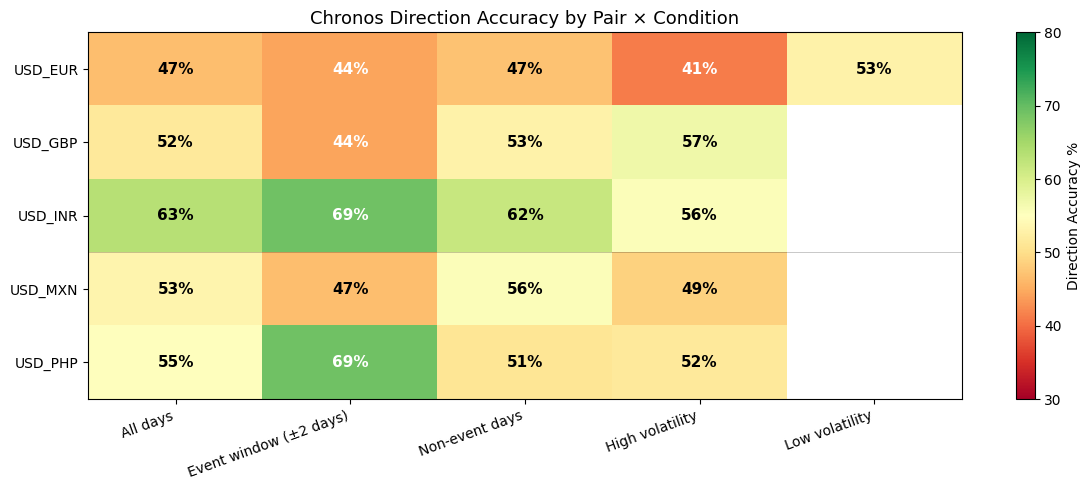

In [9]:
# Build a heatmap of direction accuracy by pair × condition

pivot_data = chronos_cond_df.pivot(index='pair', columns='condition', values='direction_acc')

# Order columns logically
column_order = ['All days', 'Event window (±2 days)', 'Non-event days', 'High volatility', 'Low volatility']
pivot_data = pivot_data[[c for c in column_order if c in pivot_data.columns]]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot_data.values, cmap='RdYlGn', vmin=30, vmax=80, aspect='auto')

ax.set_xticks(range(len(pivot_data.columns)))
ax.set_xticklabels(pivot_data.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot_data.index)))
ax.set_yticklabels(pivot_data.index)

# Add value labels
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        val = pivot_data.values[i, j]
        if not np.isnan(val):
            color = 'white' if (val < 45 or val > 65) else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', 
                    color=color, fontsize=11, fontweight='bold')

ax.axhline(2.5, color='black', linewidth=0.5, alpha=0.3)
plt.colorbar(im, label='Direction Accuracy %')
plt.title('Chronos Direction Accuracy by Pair × Condition', fontsize=13)
plt.tight_layout()
plt.savefig('conditional_direction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
conditional_output = {
    'chronos_direction': chronos_cond_df.to_dict('records'),
    'garch_volatility': garch_cond_df.to_dict('records')
}

with open('conditional_results.json', 'w') as f:
    json.dump(conditional_output, f, indent=2, default=str)

print("Conditional analysis saved to conditional_results.json")
print("\n=== Summary of Conditional Findings ===\n")
print("Look for patterns:")
print("1. Does Chronos direction accuracy increase around central bank events?")
print("2. Does GARCH perform better in high-vol regimes?")
print("3. Are interval calibrations consistent across conditions?")
print("\nIf the answer is YES to any of these, that's a product-relevant insight.")
print("If NO, your model behavior is regime-agnostic (also useful to know).")

Conditional analysis saved to conditional_results.json

=== Summary of Conditional Findings ===

Look for patterns:
1. Does Chronos direction accuracy increase around central bank events?
2. Does GARCH perform better in high-vol regimes?
3. Are interval calibrations consistent across conditions?

If the answer is YES to any of these, that's a product-relevant insight.
If NO, your model behavior is regime-agnostic (also useful to know).
